In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [41]:
TRAIN_FILE=r"..\data\rul_train.csv"
TEST_FILE=r"..\data\rul_test.csv"
VALIDATION_FILE=r"..\data\rul_validation.csv"

In [42]:
MODEL_FILE=r"..\models\xgboost_rul_model.json"

In [43]:
train=pd.read_csv(TRAIN_FILE)
train.head()

,engine_id,timestamp_hours,mission_type,altitude_m,ambient_temp_C,pressure_kPa,air_density_kg_m3,throttle,load,rpm,air_mass_flow_kg_s,fuel_flow_kg_s,torque_Nm,power_W,cht_C,egt_C,oil_temperature_C,oil_pressure_bar,vibration_rms,rul_hours,rpm_lag_1,rpm_lag_3,rpm_lag_6,rpm_lag_12,cht_C_lag_1,cht_C_lag_3,cht_C_lag_6,cht_C_lag_12,egt_C_lag_1,egt_C_lag_3,egt_C_lag_6,egt_C_lag_12,oil_temperature_C_lag_1,oil_temperature_C_lag_3,oil_temperature_C_lag_6,oil_temperature_C_lag_12,oil_pressure_bar_lag_1,oil_pressure_bar_lag_3,oil_pressure_bar_lag_6,oil_pressure_bar_lag_12,...,oil_temperature_C_std_12,oil_pressure_bar_std_3,oil_pressure_bar_std_6,oil_pressure_bar_std_12,vibration_rms_std_3,vibration_rms_std_6,vibration_rms_std_12,fuel_flow_kg_s_std_3,fuel_flow_kg_s_std_6,fuel_flow_kg_s_std_12,power_W_std_3,power_W_std_6,power_W_std_12,torque_Nm_std_3,torque_Nm_std_6,torque_Nm_std_12,rpm_slope_6,rpm_slope_12,cht_C_slope_6,cht_C_slope_12,egt_C_slope_6,egt_C_slope_12,oil_temperature_C_slope_6,oil_temperature_C_slope_12,oil_pressure_bar_slope_6,oil_pressure_bar_slope_12,vibration_rms_slope_6,vibration_rms_slope_12,fuel_flow_kg_s_slope_6,fuel_flow_kg_s_slope_12,power_W_slope_6,power_W_slope_12,rpm_delta,cht_C_delta,egt_C_delta,oil_temperature_C_delta,oil_pressure_bar_delta,vibration_rms_delta,fuel_flow_kg_s_delta,power_W_delta
0,ENG_0001,2.000000,mixed,2000.000000,27.000000,79.495009,0.922665,0.78,0.766603,6059.784870,0.078698,0.005946,110.513093,70098.119325,116.376022,375.691860,56.672138,3.939651,0.259875,776.476928,6051.471815,6066.407116,1098.547785,6063.517592,116.793684,117.393675,116.854998,116.506283,378.129176,377.852134,377.427021,397.592793,56.895971,56.964670,57.149704,66.878622,3.882365,3.922272,1.539414,3.573905,...,1.630418,0.032081,0.974254,1.164369,0.022210,0.033061,0.034355,0.000660,0.002462,0.002121,7819.464809,28993.157546,24998.265450,12.335303,141.909981,165.669423,4961.237085,-1.866361,-0.478975,-0.065130,-1.735161,-10.950467,-0.477566,-5.103242,2.400236,0.182873,0.057705,-0.003857,0.002082,2.485744e-03,24474.173379,29303.402399,8.313055,-0.417661,-2.437316,-0.223833,0.057286,0.002143,0.000120,1363.884169
1,ENG_0001,2.166667,mixed,4000.000000,14.000000,61.639907,0.747817,0.78,0.808359,6063.726292,0.063828,0.004837,89.888058,57041.135283,117.028429,376.304020,56.545367,3.854543,0.269814,776.310261,6059.784870,6058.440761,6053.250662,6064.890165,116.376022,116.443768,116.487808,116.996178,375.691860,377.226217,376.396222,380.092625,56.672138,57.072599,57.271366,62.229648,3.939651,3.936033,3.874329,3.763171,...,0.882220,0.043396,0.972820,1.169447,0.006447,0.032520,0.034684,0.000608,0.001987,0.002122,7177.204620,23406.407643,25000.945349,11.321982,133.051153,165.666016,10.475630,-0.581937,0.540621,0.016126,-0.092202,-1.894303,-0.725999,-2.842140,-0.019786,0.045686,-0.005649,0.002895,0.004270,2.548618e-06,50275.500587,19.012545,3.941422,0.652406,0.612160,-0.126771,-0.085108,0.009940,-0.001109,-13056.984042
2,ENG_0001,2.333333,mixed,6000.000000,1.000000,47.180642,0.599540,0.78,0.770982,1099.525447,0.051134,0.003872,395.614348,45568.183189,117.292515,377.364508,57.234847,1.528501,0.190910,776.143594,6063.726292,6051.471815,1096.199912,1102.463918,117.028429,116.793684,116.945094,117.110237,376.304020,378.129176,376.137022,378.113718,56.545367,56.895971,56.538061,59.692494,3.854543,3.882365,1.525446,1.490585,...,0.476151,1.368171,0.971573,1.164747,0.042975,0.035049,0.036427,0.001038,0.001986,0.002122,12273.489241,23402.650308,25003.145372,170.868703,133.395685,165.755357,3.325535,-1.469235,0.347421,0.091139,1.227485,-0.374605,0.696786,-1.228824,0.003055,0.018958,-0.006950,-0.007283,0.000010,6.721521e-06,85.680750,38.373285,-4964.200845,0.264087,1.060488,0.689480,-2.326042,-0.078905,-0.000966,-11472.952094
3,ENG_0001,2.500000,mixed,8000.000000,-12.000000,35.599413,0.474892,0.62,0.609055,6066.894663,0.005958,0.000443,8.341465,5241.600730,116.492109,377.621992,56.751815,3.886397,0.266454,775.976928,1099.525447,6059.784870,6066.4071

In [44]:
val=pd.read_csv(VALIDATION_FILE)
test=pd.read_csv(TEST_FILE)

In [45]:
print(len(train))
print(len(val))
print(len(test))

660269
128023
141022


In [46]:

X_train=train.drop(
    columns=["engine_id","mission_type","rul_hours"]
)

In [47]:
x_val=val.drop(
    columns=["engine_id","mission_type","rul_hours"]
)

In [48]:
X_test=test.drop(
    columns=["engine_id","mission_type","rul_hours"]
)

In [49]:
y_train=train["rul_hours"]
y_val=val["rul_hours"]
y_test=test["rul_hours"]

In [50]:
X_val=x_val[X_train.columns]
X_test=X_test[X_train.columns]


In [51]:
model=XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)


In [52]:
model.fit(
    X_train,y_train,
    eval_set=[(X_train,y_train),(X_val,y_val)],
    verbose=False
)
print("Done")

Done


In [53]:
train_pred=model.predict(X_train)
val_pred=model.predict(X_val)
test_pred=model.predict(X_test)

In [54]:
def testing_model(name,y_true,y_pred):
    mae=mean_absolute_error(y_true,y_pred)
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    r2=r2_score(y_true,y_pred)
    print(f"\n {name}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2: {r2:.6f}")

    return mae,rmse,r2



In [55]:
train_met=testing_model("Train",y_train,train_pred)
print("")
val_met=testing_model("Validation",y_val,val_pred)
print(" ")
test_met=testing_model("Testing",y_test,test_pred)



 Train
MAE: 15.384470
RMSE: 26.216987
R2: 0.987159


 Validation
MAE: 34.150295
RMSE: 72.465177
R2: 0.901169
 

 Testing
MAE: 34.095603
RMSE: 70.557896
R2: 0.900713


In [56]:
imp=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":model.feature_importances_
})

imp=imp.sort_values(
    "Importance",
    ascending=False
)

In [57]:
print(imp.head(30).to_string(index=False))

                 Feature  Importance
    vibration_rms_mean_3    0.356223
    vibration_rms_mean_6    0.288870
     vibration_rms_lag_1    0.082599
   vibration_rms_mean_12    0.037148
     vibration_rms_lag_3    0.033310
           vibration_rms    0.025696
        oil_pressure_bar    0.015185
  oil_pressure_bar_lag_1    0.013554
         timestamp_hours    0.012066
  oil_pressure_bar_lag_3    0.010034
  oil_pressure_bar_lag_6    0.009618
 oil_pressure_bar_mean_3    0.008325
        power_W_slope_12    0.007778
     vibration_rms_lag_6    0.006459
 oil_pressure_bar_mean_6    0.005838
 oil_pressure_bar_lag_12    0.005772
 fuel_flow_kg_s_slope_12    0.004691
          power_W_mean_6    0.003693
oil_pressure_bar_mean_12    0.003230
          power_W_std_12    0.003000
         power_W_mean_12    0.002586
       torque_Nm_mean_12    0.002556
  fuel_flow_kg_s_mean_12    0.002489
          power_W_lag_12    0.002177
           power_W_std_6    0.002120
        torque_Nm_mean_6    0.002074
 

In [58]:
model.save_model(
    MODEL_FILE
)



In [59]:
prediction_output=test[
    [
        "engine_id",
        "timestamp_hours",
        "rul_hours"
    ]
].copy()

In [60]:
prediction_output["predicted_rul_hours"]=test_pred

In [61]:
prediction_output["error_hours"]=(
    prediction_output["predicted_rul_hours"]
    -prediction_output["rul_hours"]
)

In [62]:
prediction_output.to_csv(
    r"..\data\rul_test_predictions.csv",
    index=False
)

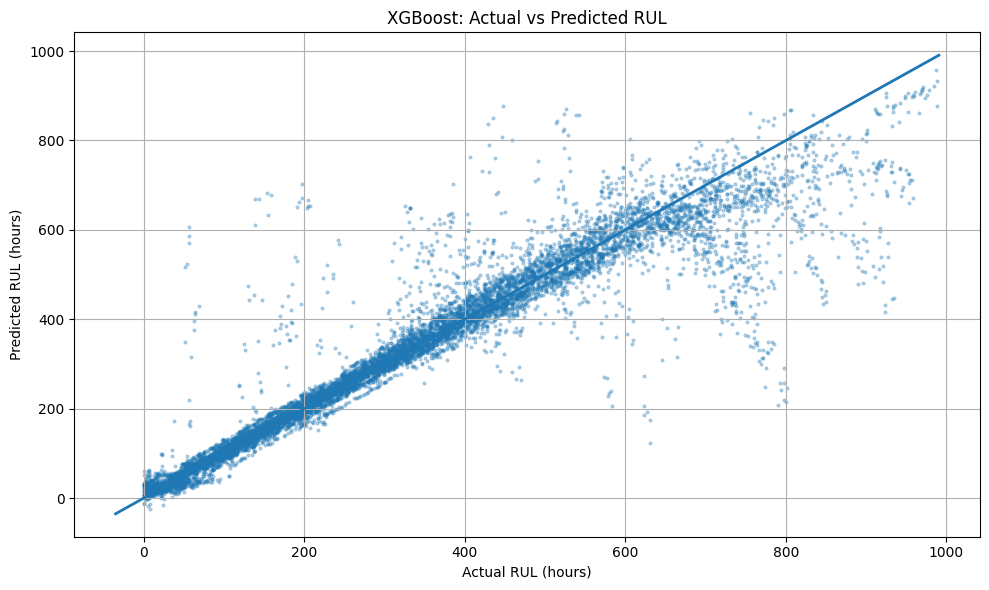

In [63]:

sample_size=min(
    10000,
    len(y_test)
)

sample_indices=np.random.default_rng(
    42
).choice(
    len(y_test),
    size=sample_size,
    replace=False
)

plt.figure(
    figsize=(10,6)
)

plt.scatter(
    y_test.iloc[sample_indices],
    test_pred[sample_indices],
    s=4,
    alpha=0.3
)

min_value=min(
    y_test.min(),
    test_pred.min()
)

max_value=max(
    y_test.max(),
    test_pred.max()
)

plt.plot(
    [min_value,max_value],
    [min_value,max_value],
    linewidth=2
)

plt.xlabel(
    "Actual RUL (hours)"
)

plt.ylabel(
    "Predicted RUL (hours)"
)

plt.title(
    "XGBoost: Actual vs Predicted RUL"
)

plt.grid(True)

plt.tight_layout()

plt.show()

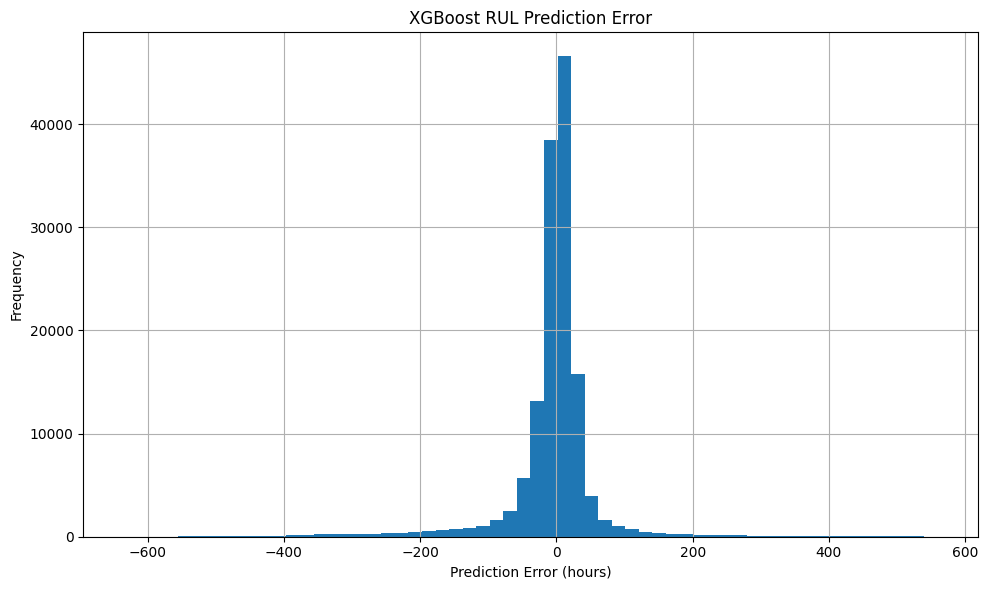

In [64]:
errors=(
    test_pred
    -y_test.to_numpy()
)

plt.figure(
    figsize=(10,6)
)

plt.hist(
    errors,
    bins=60
)

plt.xlabel(
    "Prediction Error (hours)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "XGBoost RUL Prediction Error"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [65]:
print("\n====================================")
print("XGBOOST RUL TRAINING COMPLETE")
print("====================================")

print(
    f"Test MAE : {test_met[0]:.6f} hours"
)

print(
    f"Test RMSE: {test_met[1]:.6f} hours"
)

print(
    f"Test R²  : {test_met[2]:.6f}"
)


XGBOOST RUL TRAINING COMPLETE
Test MAE : 34.095603 hours
Test RMSE: 70.557896 hours
Test R²  : 0.900713
